# 4.2 Dataset Statistics
**Children's Stories Fine-Tuning — DiabAI NLP Mini Project**

This notebook reproduces the dataset analysis for Section 4.2 of the report.
It subsamples 10,000 stories from `ajibawa-2023/Children-Stories-Collection`,
assigns synthetic age-level labels (round-robin, same as fine-tuning), and
produces Figure 3: distribution of story lengths and age-level categories.

In [1]:
# ── Install ────────────────────────────────────────────────────
!pip install -q datasets matplotlib seaborn

In [2]:
# ── Imports ────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from datasets import load_dataset

SAMPLE_SIZE = 10_000
SEED        = 42
PREFIXES    = [
    'Age 3–4  (Simple words)',
    'Age 5–6  (Short sentences)',
    'Age 7–8  (Moderate vocabulary)',
    'Age 9–10 (Longer sentences)',
    'Age 11–12 (Richer vocabulary)',
]

# ── Load dataset ───────────────────────────────────────────────
print('Loading dataset...')
ds = load_dataset('ajibawa-2023/Children-Stories-Collection', split='train')
ds = ds.shuffle(seed=SEED).select(range(min(SAMPLE_SIZE, len(ds))))
print(f'Loaded {len(ds)} samples.')

Loading dataset...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/625 [00:00<?, ?B/s]

Children-Stories-0-Final.json:   0%|          | 0.00/344M [00:00<?, ?B/s]

Children-Stories-1-Final.json:   0%|          | 0.00/346M [00:00<?, ?B/s]

...

Children-Stories-7-Final.json:   0%|          | 0.00/346M [00:00<?, ?B/s]

Children-Stories-8-Final.json:   0%|          | 0.00/345M [00:00<?, ?B/s]

Children-Stories-9-Final.json:   0%|          | 0.00/342M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/896668 [00:00<?, ? examples/s]

Loaded 10000 samples.


In [3]:
# ── Build DataFrame ────────────────────────────────────────────
records = []
for i, ex in enumerate(ds):
    text        = ex.get('text', '')
    prompt      = ex.get('prompt', '')
    level_label = PREFIXES[i % len(PREFIXES)]
    level_idx   = i % len(PREFIXES)

    # Lengths in words and characters
    word_len = len(text.split())
    char_len = len(text)

    # Build the full formatted sample (as seen by the model)
    formatted = (
        f'<start_of_turn>user\n{level_label}\n{prompt}<end_of_turn>\n'
        f'<start_of_turn>model\n{text}<end_of_turn>\n'
    )
    token_approx = len(formatted.split())   # rough word-level token proxy

    records.append({
        'level_label': level_label,
        'level_idx':   level_idx,
        'word_len':    word_len,
        'char_len':    char_len,
        'token_approx': token_approx,
    })

df = pd.DataFrame(records)
print(df.describe().round(1))

       level_idx  word_len  char_len  token_approx
count    10000.0   10000.0   10000.0       10000.0
mean         2.0     324.1    2038.0         591.0
std          1.4      55.0     373.7          71.0
min          0.0      42.0     329.0         288.0
25%          1.0     287.0    1785.0         550.0
50%          2.0     321.0    2015.0         596.0
75%          3.0     358.0    2270.0         637.0
max          4.0     589.0    3957.0         886.0


In [4]:
# ── Summary stats table ────────────────────────────────────────
print('\n── SUMMARY ──────────────────────────────────────────')
print(f'  Total samples        : {len(df):,}')
print(f'  Train split (95%)    : {int(len(df)*0.95):,}')
print(f'  Eval  split  (5%)    : {int(len(df)*0.05):,}')
print(f'  Median story length  : {df.word_len.median():.0f} words')
print(f'  Mean  story length   : {df.word_len.mean():.0f} words')
print(f'  Std   story length   : {df.word_len.std():.0f} words')
print(f'  Min / Max            : {df.word_len.min()} / {df.word_len.max()} words')
print()
print('  Samples per age level (round-robin → perfectly balanced):')
for lbl, cnt in df.level_label.value_counts().sort_index().items():
    print(f'    {lbl:40s} {cnt:,}')


── SUMMARY ──────────────────────────────────────────
  Total samples        : 10,000
  Train split (95%)    : 9,500
  Eval  split  (5%)    : 500
  Median story length  : 321 words
  Mean  story length   : 324 words
  Std   story length   : 55 words
  Min / Max            : 42 / 589 words

  Samples per age level (round-robin → perfectly balanced):
    Age 11–12 (Richer vocabulary)            2,000
    Age 3–4  (Simple words)                  2,000
    Age 5–6  (Short sentences)               2,000
    Age 7–8  (Moderate vocabulary)           2,000
    Age 9–10 (Longer sentences)              2,000


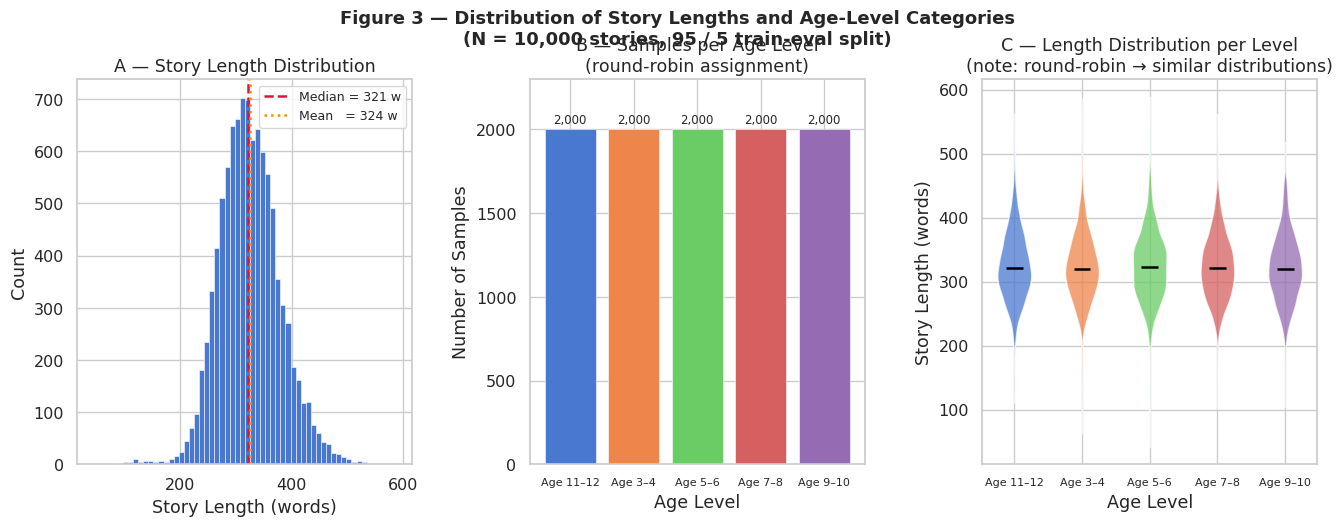


✅ Figure 3 saved as figure3_dataset_statistics.png


In [5]:
# ── FIGURE 3 ───────────────────────────────────────────────────
# Layout: 3 panels
#   Left  : story length histogram (words)
#   Middle: age-level bar chart
#   Right : length violin per age level

PALETTE = sns.color_palette('muted', n_colors=5)
sns.set_theme(style='whitegrid', font_scale=1.05)

fig = plt.figure(figsize=(16, 5))
fig.suptitle(
    'Figure 3 — Distribution of Story Lengths and Age-Level Categories\n'
    f'(N = {len(df):,} stories, 95 / 5 train-eval split)',
    fontsize=13, fontweight='bold', y=1.02
)
gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

# ── Panel A: Story length histogram ───────────────────────────
ax1 = fig.add_subplot(gs[0])
ax1.hist(
    df['word_len'], bins=60,
    color=PALETTE[0], edgecolor='white', linewidth=0.4
)
ax1.axvline(df.word_len.median(), color='crimson', lw=1.8,
            linestyle='--', label=f'Median = {df.word_len.median():.0f} w')
ax1.axvline(df.word_len.mean(),   color='darkorange', lw=1.8,
            linestyle=':',  label=f'Mean   = {df.word_len.mean():.0f} w')
ax1.set_xlabel('Story Length (words)')
ax1.set_ylabel('Count')
ax1.set_title('A — Story Length Distribution')
ax1.legend(fontsize=9)

# ── Panel B: Age-level bar chart ───────────────────────────────
ax2 = fig.add_subplot(gs[1])
level_counts = df.level_label.value_counts().sort_index()
short_labels  = [f'Age {l.split()[1]}' for l in level_counts.index]
bars = ax2.bar(
    short_labels, level_counts.values,
    color=PALETTE, edgecolor='white', linewidth=0.4
)
for bar, val in zip(bars, level_counts.values):
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 20,
        f'{val:,}', ha='center', va='bottom', fontsize=8.5
    )
ax2.set_xlabel('Age Level')
ax2.set_ylabel('Number of Samples')
ax2.set_title('B — Samples per Age Level\n(round-robin assignment)')
ax2.set_ylim(0, level_counts.max() * 1.15)
ax2.tick_params(axis='x', labelsize=8)

# ── Panel C: Length violin per age level ──────────────────────
ax3 = fig.add_subplot(gs[2])
order  = sorted(df.level_label.unique())
labels = [f'Age {l.split()[1]}' for l in order]
data_per_level = [df[df.level_label == lvl]['word_len'].values for lvl in order]

vp = ax3.violinplot(
    data_per_level,
    positions=range(len(order)),
    showmedians=True, showextrema=False
)
for i, body in enumerate(vp['bodies']):
    body.set_facecolor(PALETTE[i])
    body.set_alpha(0.75)
vp['cmedians'].set_color('black')
vp['cmedians'].set_linewidth(1.8)

ax3.set_xticks(range(len(order)))
ax3.set_xticklabels(labels, fontsize=8)
ax3.set_xlabel('Age Level')
ax3.set_ylabel('Story Length (words)')
ax3.set_title('C — Length Distribution per Level\n(note: round-robin → similar distributions)')

plt.savefig('figure3_dataset_statistics.png', dpi=180, bbox_inches='tight')
plt.show()
print('\n✅ Figure 3 saved as figure3_dataset_statistics.png')

In [6]:
# ── Report-ready caption ───────────────────────────────────────
caption = f"""
Figure 3. Distribution of story lengths and age-level categories in the training sample.

We subsampled {len(df):,} stories from the Children's Stories Collection dataset
[ajibawa-2023], retaining {int(len(df)*0.95):,} samples for training and
{int(len(df)*0.05):,} for evaluation (95/5 split, random seed 42).
Panel A shows the story length distribution in words (median: {df.word_len.median():.0f},
mean: {df.word_len.mean():.0f} ± {df.word_len.std():.0f}).
Panel B shows the per-level sample counts; since labels are assigned by round-robin
cycling (index mod 5), all five age levels are perfectly balanced with
approximately {level_counts.values.mean():.0f} samples each.
Panel C confirms that because the assignment is positional rather than semantic,
the story length distributions are nearly identical across all five age levels —
the model learns the age-level response format from the instruction prefix rather
than from inherent length differences in the training stories.
"""
print(caption)


Figure 3. Distribution of story lengths and age-level categories in the training sample.

We subsampled 10,000 stories from the Children's Stories Collection dataset
[ajibawa-2023], retaining 9,500 samples for training and
500 for evaluation (95/5 split, random seed 42).
Panel A shows the story length distribution in words (median: 321,
mean: 324 ± 55).
Panel B shows the per-level sample counts; since labels are assigned by round-robin
cycling (index mod 5), all five age levels are perfectly balanced with
approximately 2000 samples each.
Panel C confirms that because the assignment is positional rather than semantic,
the story length distributions are nearly identical across all five age levels —
the model learns the age-level response format from the instruction prefix rather
than from inherent length differences in the training stories.

